# Pipeline Integral - Abastecimiento y Logística
Este notebook contiene el pipeline completo:

Limpieza segura → Correlación → PCA → Balanceo → Red Neuronal → Exportación de Modelos (.pkl)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymongo
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)
print("✅ Librerías cargadas y carpetas creadas.")


✅ Librerías cargadas y carpetas creadas.


## 1. Carga de Datos desde MongoDB y Flattening

In [2]:
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["ProyectoBueno"]
collection = db["fact_abastecimiento"]
data = list(collection.find())
print(f"✅ Registros cargados: {len(data)}")

def flatten_dict(d, parent_key='', sep='_'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        elif isinstance(v, list):
            items.append((new_key, str(v)))
        else:
            items.append((new_key, v))
    return dict(items)

flat_data = [flatten_dict(record) for record in data]
df = pd.DataFrame(flat_data)
print(f"📊 Dimensiones iniciales aplanadas: {df.shape}")


✅ Registros cargados: 8500
📊 Dimensiones iniciales aplanadas: (8500, 26)


## 2. Creación del 'Y' Objetivo

In [3]:
# Calculamos el ratio de entrega
if 'cantidad_recibida' in df.columns and 'cantidad_solicitada' in df.columns:
    df['cantidad_recibida'] = pd.to_numeric(df['cantidad_recibida'], errors='coerce').fillna(0)
    df['cantidad_solicitada'] = pd.to_numeric(df['cantidad_solicitada'], errors='coerce').fillna(1)
    df['cantidad_solicitada'] = df['cantidad_solicitada'].replace(0, 1)
    ratio = df['cantidad_recibida'] / df['cantidad_solicitada']

    # Terciles relativos: garantiza SIEMPRE 3 clases balanceadas
    try:
        df['y_target'] = pd.qcut(ratio, q=3, labels=[0, 1, 2], duplicates='drop').astype(int)
        n_clases = df['y_target'].nunique()
        if n_clases < 3:
            raise ValueError("qcut produjo menos de 3 clases")
        print("✅ Target 'y_target' creado con Terciles Relativos (3 clases).")
    except (ValueError, TypeError):
        # Fallback: usar percentiles manuales para forzar 3 clases
        p33 = ratio.quantile(0.33)
        p66 = ratio.quantile(0.66)
        df['y_target'] = np.where(ratio <= p33, 0, np.where(ratio <= p66, 1, 2))
        print("✅ Target 'y_target' creado con percentiles manuales (3 clases).")
else:
    numeric_cols_temp = df.select_dtypes(include=[np.number]).columns
    df['y_target'] = (df[numeric_cols_temp[0]] > df[numeric_cols_temp[0]].median()).astype(int)
    print("⚠️ Target binario creado como fallback.")

print(df['y_target'].value_counts().sort_index())


✅ Target 'y_target' creado con Terciles Relativos (3 clases).
y_target
0    2835
1    2832
2    2833
Name: count, dtype: int64


## 3. Feature Engineering, Limpieza Segura e Imputación

In [4]:
# --- A. INGENIERÍA DE CARACTERÍSTICAS (Extrayendo oro de las fechas) ---
print("⚙️ Aplicando Feature Engineering...")
fechas_cols = [c for c in df.columns if 'fecha' in c.lower()]
for col in fechas_cols:
    try:
        # Convertimos a datetime
        df_dt = pd.to_datetime(df[col], errors='coerce')
        # Extraemos el mes y el día de la semana (0=Lunes, 6=Domingo)
        df[f'{col}_mes'] = df_dt.dt.month
        df[f'{col}_dia_semana'] = df_dt.dt.dayofweek
    except:
        pass

# --- B. FILTRO SEGURO Y PREVENCIÓN DE FUGA DE DATOS ---
# CRÍTICO: Eliminamos las variables con las que calculamos el Y
cols_to_drop = ['cantidad_recibida', 'cantidad_solicitada'] 

for col in df.columns:
    cl = col.lower()
    is_id = (cl == 'id' or cl == '_id' or cl == '_collection'
             or cl.startswith('id_') or cl.endswith('_id')
             or '_id_' in cl or 'id_venta_dw' in cl)
    # Agregamos las columnas de fecha originales para borrarlas, ya que salvamos el mes/día
    is_junk = ('telefono' in cl or 'correo' in cl or 'email' in cl
               or 'codigo_barras' in cl or 'codigo_producto' in cl
               or cl in fechas_cols)
    
    if (is_id or is_junk) and col != 'y_target' and col not in cols_to_drop:
        cols_to_drop.append(col)

df_clean = df.drop(columns=cols_to_drop, errors='ignore')
print(f"✅ Fuga de datos corregida y {len(cols_to_drop)} columnas basura eliminadas.")
print(f"📊 Dimensiones limpias (con features nuevas): {df_clean.shape}")

# Separar Target de Features
y = df_clean['y_target'].copy()
X_raw = df_clean.drop(columns=['y_target']).copy()

# Identificar tipos
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

# IMPUTACIÓN
for col in numeric_cols:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())
for col in categorical_cols:
    mode_val = X_raw[col].mode()
    fill_val = mode_val.iloc[0] if not mode_val.empty else 'UNKNOWN'
    X_raw[col] = X_raw[col].fillna(fill_val)

print("✅ Valores nulos imputados correctamente.")


⚙️ Aplicando Feature Engineering...
✅ Fuga de datos corregida y 3 columnas basura eliminadas.
📊 Dimensiones limpias (con features nuevas): (8500, 24)
✅ Valores nulos imputados correctamente.


## 4. Codificación (Frontend-Safe) y Normalización

In [5]:
# ONE-HOT ENCODER PREPARADO PARA PRODUCCIÓN
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_encoded = encoder.fit_transform(X_raw[categorical_cols])

feature_names = encoder.get_feature_names_out(categorical_cols)
X_cat_df = pd.DataFrame(X_cat_encoded, columns=feature_names, index=X_raw.index)

X_numeric = X_raw[numeric_cols]
X_encoded = pd.concat([X_numeric, X_cat_df], axis=1)

print(f"📊 Dimensiones tras One-Hot: {X_encoded.shape}")

# NORMALIZACIÓN
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_scaled_arr = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled_arr, columns=X_encoded.columns, index=X_encoded.index)
print("✅ Datos normalizados.")


📊 Dimensiones tras One-Hot: (8500, 58)
✅ Datos normalizados.


## 5. Análisis de Correlación (Filtro Antirruido)

In [6]:
corr_matrix = X_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.90)]

X_uncorrelated = X_scaled.drop(columns=to_drop_corr)
print(f"✅ Columnas altamente correlacionadas eliminadas: {len(to_drop_corr)}")
print(f"📊 Dimensiones sin redundancia: {X_uncorrelated.shape}")


✅ Columnas altamente correlacionadas eliminadas: 5
📊 Dimensiones sin redundancia: (8500, 53)


## 6. PCA: Reducción de Dimensionalidad para Entrenamiento

In [7]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_uncorrelated)

print(f"✅ PCA Completado.")
print(f"📊 Dimensiones FINALES para la Red Neuronal: {X_pca.shape}")
print(f"📈 Con {X_pca.shape[1]} componentes explicamos el 95% de la varianza.")


✅ PCA Completado.
📊 Dimensiones FINALES para la Red Neuronal: (8500, 23)
📈 Con 23 componentes explicamos el 95% de la varianza.


## 7. Balanceo de Clases (SMOTE - Synthetic Minority Over-sampling)

In [8]:
# Importación necesaria (asegúrate de tener imblearn instalado)
from imblearn.over_sampling import SMOTE

print("⚖️ Balanceando clases con SMOTE...")

# Aplicamos SMOTE directamente sobre los datos reducidos por PCA
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_pca, y)

print("✅ Clases Balanceadas exitosamente (Sin duplicados exactos):")
for c, count in zip(*np.unique(y_bal, return_counts=True)):
    print(f"  Clase {c}: {count} muestras")


⚖️ Balanceando clases con SMOTE...
✅ Clases Balanceadas exitosamente (Sin duplicados exactos):
  Clase 0: 2835 muestras
  Clase 1: 2835 muestras
  Clase 2: 2835 muestras


## 8. Entrenamiento de la Red Neuronal (El Cerebro)

🧠 Entrenando Red Neuronal (MLPClassifier)...
✅ Entrenamiento completado en 13 épocas.
🎯 Accuracy en Test: 77.60%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       567
           1       0.67      0.81      0.73       567
           2       0.83      0.79      0.81       567

    accuracy                           0.78      1701
   macro avg       0.79      0.78      0.78      1701
weighted avg       0.79      0.78      0.78      1701



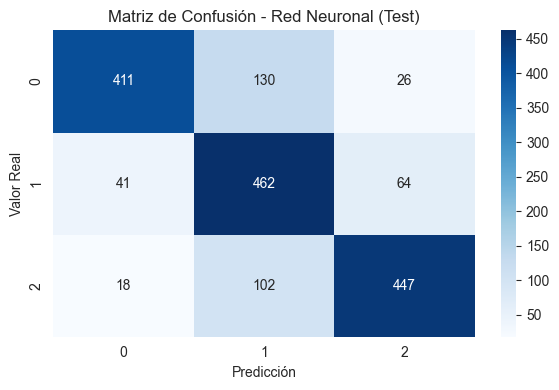

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

print("🧠 Entrenando Red Neuronal (MLPClassifier)...")
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True)

nn_model.fit(X_train, y_train)
y_pred = nn_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"✅ Entrenamiento completado en {nn_model.n_iter_} épocas.")
print(f"🎯 Accuracy en Test: {acc*100:.2f}%")
print()
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Red Neuronal (Test)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.savefig('outputs/01_confusion_matrix.png')
plt.show()


## 9. Dashboard Visual de Dispersión (t-SNE) [Solo Reporte]

🎨 Generando dashboard visual de separabilidad con t-SNE...
✅ Silhouette Score de la dispersión: 0.1661


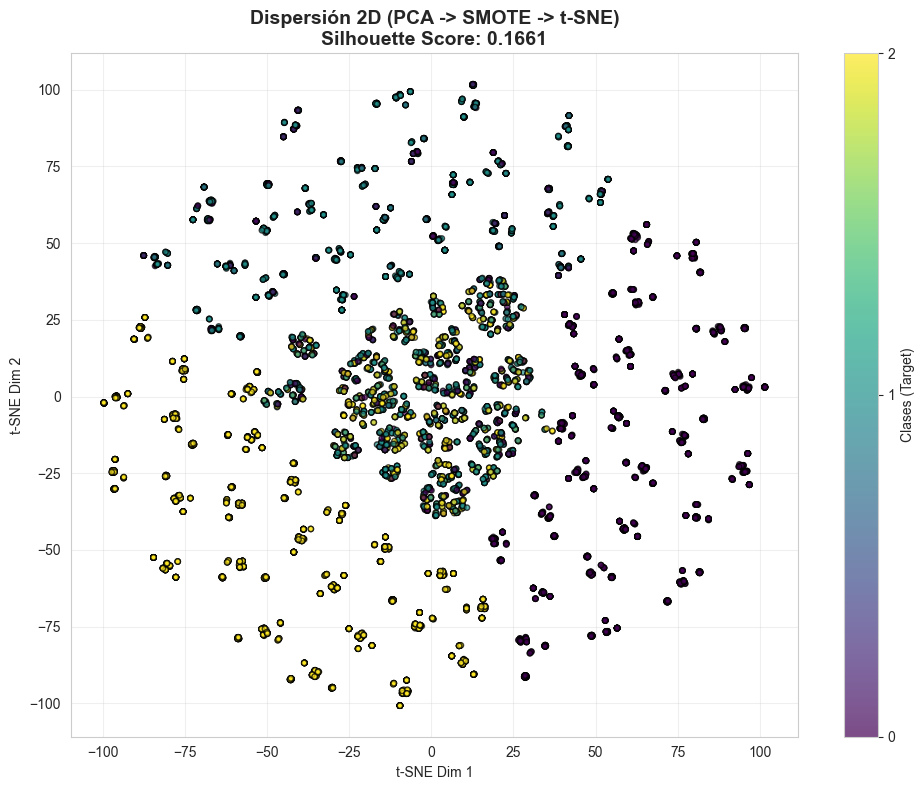

In [10]:
print("🎨 Generando dashboard visual de separabilidad con t-SNE...")

# t-SNE se alimenta directamente de X_bal (Alta dimensionalidad proveniente de PCA+SMOTE)
# Ajustamos perplexity a un valor estándar seguro (ej. 30)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_visual = tsne.fit_transform(X_bal)

sil_score = silhouette_score(X_tsne_visual, y_bal)
print(f"✅ Silhouette Score de la dispersión: {sil_score:.4f}")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne_visual[:, 0], X_tsne_visual[:, 1],
                      c=y_bal, cmap='viridis', alpha=0.7, edgecolors='k', s=15)

plt.title(f'Dispersión 2D (PCA -> SMOTE -> t-SNE)\nSilhouette Score: {sil_score:.4f}',
          fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.colorbar(scatter, ticks=np.unique(y_bal), label='Clases (Target)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/02_dispersion_tsne_corregido.png', dpi=150)
plt.show()


## 10. Guardado Final para el Frontend (Archivos .pkl)

In [11]:
print("💾 Exportando moldes y modelo para el Frontend...")

joblib.dump(encoder, 'models/01_onehot_encoder.pkl')
joblib.dump(scaler, 'models/02_scaler.pkl')
joblib.dump(to_drop_corr, 'models/03_cols_to_drop_corr.pkl')
joblib.dump(pca, 'models/04_pca.pkl')
joblib.dump(nn_model, 'models/05_neural_network.pkl')

print("✅ ¡Exportación exitosa! Archivos .pkl en la carpeta 'models/'.")
print("🚀 EL BACKEND ESTÁ LISTO PARA PRODUCCIÓN.")


💾 Exportando moldes y modelo para el Frontend...
✅ ¡Exportación exitosa! Archivos .pkl en la carpeta 'models/'.
🚀 EL BACKEND ESTÁ LISTO PARA PRODUCCIÓN.
